# Fraud Detection on BankSim Transactions

## Project Overview

This project develops a machine learning system to detect fraudulent transactions using the **BankSim synthetic banking dataset**.

The system analyzes customer transaction behavior and identifies anomalies that may indicate fraudulent activity.

Unlike traditional fraud detection systems that only output a binary prediction, this project introduces a **dual scoring framework**:

- **Fraud Likelihood** – probability that a transaction is fraudulent
- **Detection Confidence** – reliability of the fraud prediction based on behavioral consistency

This approach helps distinguish between isolated anomalies and persistent suspicious behavior.

# Dataset Description

The dataset used in this project is **BankSim**, a synthetic dataset generated by an agent-based simulator of bank payments.

The simulator models realistic banking behavior and injects fraudulent transactions to simulate real-world fraud scenarios.

### Key Dataset Characteristics

- ~594,000 transactions
- ~7,200 fraudulent transactions
- ~1.2% fraud rate
- Transactions simulated over 6 months

### Key Features

| Feature | Description |
|------|------|
| step | Time step of transaction |
| customer | Customer ID |
| age | Age group |
| gender | Customer gender |
| zipcodeOri | Customer location |
| merchant | Merchant ID |
| zipMerchant | Merchant location |
| category | Transaction category |
| amount | Transaction amount |
| fraud | Fraud label (0 = normal, 1 = fraud) |

The dataset is **synthetic but behaviorally realistic**, making it suitable for fraud detection research without privacy concerns.

# Import Libraries

This section imports the necessary Python libraries used throughout the project.

Key libraries include:

- **pandas / numpy** for data manipulation
- **matplotlib / seaborn** for visualization
- **scikit-learn** for machine learning models

In [ ]:
# Data manipulation
import pandas as pd
import numpy as np

# Data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine learning preprocessing
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

# Machine learning models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

# Evaluation metrics
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

# Optional: handling class imbalance
from sklearn.utils import resample

# Visualization style
sns.set(style="whitegrid")

# Display settings
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

# Exploratory Data Analysis (EDA)

Exploratory Data Analysis is performed to better understand the dataset and identify potential issues.

Key analysis steps include:

- Checking dataset structure
- Inspecting data types
- Analyzing statistical distributions
- Observing fraud class imbalance

Understanding these characteristics helps guide feature engineering and model selection.

In [ ]:
# Load Dataset

# Unload the dataset from the zip file
import zipfile

with zipfile.ZipFile("../bs140513_032310.zip", 'r') as zip_ref:
    zip_ref.extractall("../data")


#Load dataset
df = pd.read_csv("../data/bs140513_032310.csv")

In [ ]:
# Basic dataset overview
print("Dataset shape:", df.shape)
print("\nDataset info:")
df.info()

print("\nSummary statistics:")
display(df.describe())

# Check missing values
print("\nMissing values per column:")
print(df.isnull().sum())

In [ ]:
# Fraud distribution
plt.figure(figsize=(6,4))
sns.countplot(x='fraud', data=df)
plt.title("Fraud vs Non-Fraud Transactions")
plt.xlabel("Fraud")
plt.ylabel("Count")
plt.show()

# Percentage distribution
fraud_percent = df['fraud'].value_counts(normalize=True) * 100
print("Fraud percentage distribution:")
print(fraud_percent)

In [ ]:
# Transaction amount distribution
plt.figure(figsize=(8,5))
sns.histplot(df['amount'], bins=50, kde=True)
plt.title("Transaction Amount Distribution")
plt.xlabel("Amount")
plt.ylabel("Frequency")
plt.show()

### Transaction Amount Distribution

The histogram shows that transaction amounts are highly right-skewed. 
Most transactions involve relatively small amounts, while a small number 
of transactions have significantly larger values.

This pattern is common in financial transaction datasets where everyday 
purchases are small but occasional large payments occur.

To reduce skewness and improve model performance, a logarithmic 
transformation is applied to the transaction amount feature.

In [ ]:
df['amount_log'] = np.log1p(df['amount'])

In [ ]:
plt.figure(figsize=(8,5))
sns.histplot(df['amount_log'], bins=50, kde=True)
plt.title("Log-Transformed Transaction Amount Distribution")
plt.xlabel("Log(Amount)")
plt.ylabel("Frequency")
plt.show()

In [ ]:
# Transaction amount by fraud status
plt.figure(figsize=(8,5))
sns.boxplot(x='fraud', y='amount', data=df)
plt.title("Transaction Amount by Fraud Status")
plt.xlabel("Fraud")
plt.ylabel("Amount")
plt.show()

In [ ]:
# Transaction categories distribution
plt.figure(figsize=(10,5))
sns.countplot(y='category', data=df, order=df['category'].value_counts().index)
plt.title("Transaction Categories")
plt.xlabel("Count")
plt.ylabel("Category")
plt.show()

In [ ]:
# Fraud rate by category
fraud_by_category = df.groupby('category')['fraud'].mean().sort_values(ascending=False)

plt.figure(figsize=(10,5))
fraud_by_category.plot(kind='bar')
plt.title("Fraud Rate by Transaction Category")
plt.ylabel("Fraud Rate")
plt.xlabel("Category")
plt.show()

In [ ]:
# Fraud rate by age group
fraud_by_age = df.groupby('age')['fraud'].mean()

plt.figure(figsize=(8,5))
fraud_by_age.plot(kind='bar')
plt.title("Fraud Rate by Age Group")
plt.ylabel("Fraud Rate")
plt.xlabel("Age Group")
plt.show()

In [ ]:
# Fraud rate by gender
fraud_by_gender = df.groupby('gender')['fraud'].mean()

plt.figure(figsize=(6,4))
fraud_by_gender.plot(kind='bar')
plt.title("Fraud Rate by Gender")
plt.ylabel("Fraud Rate")
plt.xlabel("Gender")
plt.show()

In [ ]:
# Top merchants by transaction count
top_merchants = df['merchant'].value_counts().head(10)

plt.figure(figsize=(8,5))
sns.barplot(x=top_merchants.values, y=top_merchants.index)
plt.title("Top 10 Merchants by Transaction Count")
plt.xlabel("Transactions")
plt.ylabel("Merchant")
plt.show()

In [ ]:
# Transaction frequency over time (by step)
plt.figure(figsize=(10,5))
sns.histplot(df['step'], bins=50)
plt.title("Transaction Frequency Over Time")
plt.xlabel("Step")
plt.ylabel("Transactions")
plt.show()

In [ ]:
# Correlation heatmap for numeric features
numeric_cols = df.select_dtypes(include=['int64','float64'])

plt.figure(figsize=(8,6))
sns.heatmap(numeric_cols.corr(), annot=True, cmap='coolwarm')
plt.title("Feature Correlation Heatmap")
plt.show()

# Data Cleaning

Before training machine learning models, the dataset must be cleaned.

Cleaning steps include:

- Removing duplicate transactions
- Handling missing values
- Filtering invalid transaction values
- Ensuring correct data types

These steps ensure that the dataset is reliable and suitable for model training.

In [25]:
# 1. Remove duplicate records
print("Number of duplicate rows:", df.duplicated().sum())

df = df.drop_duplicates()

print("Shape after removing duplicates:", df.shape)

Number of duplicate rows: 0
Shape after removing duplicates: (594643, 11)


In [26]:
# 2. Check missing values
print("\nMissing values per column:")
print(df.isnull().sum())


Missing values per column:
step           0
customer       0
age            0
gender         0
zipcodeOri     0
merchant       0
zipMerchant    0
category       0
amount         0
fraud          0
amount_log     0
dtype: int64


In [ ]:
#3. Remove transactions with negative amounts
df = df[df['amount'] >= 0]
print("Shape after removing negative amounts:", df.shape)


Shape after removing negative amounts: (594643, 11)


In [ ]:
#4. Convert Data Types

# Convert age to string
df['age'] = df['age'].astype(str)

# Remove quotes
df['age'] = df['age'].str.replace("'", "")

# Replace unknown values
df['age'] = df['age'].replace('U', 'unknown')

# One-hot encode age groups
df = pd.get_dummies(df, columns=['age'], prefix='age')

# Convert fraud column
df['fraud'] = df['fraud'].astype(int)

# Convert step column
df['step'] = df['step'].astype(int)

Index(['step', 'customer', 'gender', 'zipcodeOri', 'merchant', 'zipMerchant',
       'category', 'amount', 'fraud', 'amount_log', 'age_0', 'age_1', 'age_2',
       'age_3', 'age_4', 'age_5', 'age_6'],
      dtype='object')


In [47]:
#4. Convert Data Types
df = pd.get_dummies(df, columns=['gender', 'category'], drop_first=True)

In [ ]:
#5. Clean String Columns
# Remove unwanted quotes from string columns
df['customer'] = df['customer'].str.replace("'", "")
df['merchant'] = df['merchant'].str.replace("'", "")


In [48]:
#6. Verify Clean Dataset
# Check dataset after cleaning
df.info()

# Check for remaining missing values
df.isnull().sum()

# View cleaned dataset
df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 594643 entries, 0 to 594642
Data columns (total 32 columns):
 #   Column                           Non-Null Count   Dtype  
---  ------                           --------------   -----  
 0   step                             594643 non-null  int64  
 1   customer                         594643 non-null  object 
 2   zipcodeOri                       594643 non-null  object 
 3   merchant                         594643 non-null  object 
 4   zipMerchant                      594643 non-null  object 
 5   amount                           594643 non-null  float64
 6   fraud                            594643 non-null  int64  
 7   amount_log                       594643 non-null  float64
 8   age_0                            594643 non-null  bool   
 9   age_1                            594643 non-null  bool   
 10  age_2                            594643 non-null  bool   
 11  age_3                            594643 non-null  bool   
 12  ag

,step,customer,zipcodeOri,merchant,zipMerchant,amount,fraud,amount_log,age_0,age_1,age_2,age_3,age_4,age_5,age_6,gender_'F',gender_'M',gender_'U',category_'es_contents',category_'es_fashion',category_'es_food',category_'es_health',category_'es_home',category_'es_hotelservices',category_'es_hyper',category_'es_leisure',category_'es_otherservices',category_'es_sportsandtoys',category_'es_tech',category_'es_transportation',category_'es_travel',category_'es_wellnessandbeauty'
0,0,C1093826151,'28007',M348934600,'28007',4.55,0,1.713798,False,False,False,False,True,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False
1,0,C352968107,'28007',M348934600,'28007',39.68,0,3.705737,False,False,True,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False
2,0,C2054744914,'28007',M1823072687,'28007',26.89,0,3.328268,False,False,False,False,True,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False
3,0,C1760612790,'28007',M348934600,'28007',17.25,0,2.904165,False,False,False,True,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False
4,0,C757503768,'28007',M348934600,'28007',35.72,0,3.603322,False,False,False,False,False,True,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False


# Feature Engineering

Feature engineering transforms raw transaction data into meaningful variables that help machine learning models detect fraud patterns.

This project focuses on **behavior-based feature engineering**, which captures deviations from normal customer behavior.

Key feature types include:

- Transaction amount transformations
- Customer spending statistics
- Transaction frequency indicators
- Merchant and category novelty detection
- Sequential anomaly tracking

These features help identify suspicious patterns that may indicate fraudulent activity.

# Behavioral Baseline Modeling

Fraud detection often relies on identifying deviations from a customer's normal transaction behavior.

To capture this behavior, rolling statistical features are computed for each customer, including:

- Rolling average transaction amount
- Rolling standard deviation of spending

These statistics represent a **behavioral baseline** that defines typical spending patterns.

Transactions that deviate significantly from this baseline may indicate suspicious activity.

In [49]:
df = df.sort_values(['customer', 'step'])

df['transaction_count'] = df.groupby('customer').cumcount()

In [50]:
df['customer_avg_amount'] = df.groupby('customer')['amount'].transform('mean')

# Anomaly Detection Features

Anomaly features measure how unusual a transaction is compared to historical behavior.

Examples include:

- Transaction amount z-score
- New merchant detection
- New category detection
- Transaction burst detection
- High deviation flags

These signals help the model identify transactions that differ from typical behavior patterns.

In [51]:
df['amount_deviation'] = df['amount'] - df['customer_avg_amount']

In [52]:
df['rolling_mean_5'] = (
    df.groupby('customer')['amount']
    .transform(lambda x: x.shift(1).rolling(5).mean())
)

In [53]:
df['rolling_std_5'] = (
    df.groupby('customer')['amount']
    .transform(lambda x: x.shift(1).rolling(5).std())
)

In [54]:
df['amount_zscore'] = (
    (df['amount'] - df['rolling_mean_5']) / df['rolling_std_5']
)

In [55]:
df['new_merchant'] = (
    df.groupby('customer')['merchant']
    .transform(lambda x: ~x.duplicated())
).astype(int)

In [56]:
df['merchant_freq'] = df.groupby(['customer','merchant']).cumcount()

In [57]:
df['recent_txn_count'] = (
    df.groupby('customer')['step']
    .transform(lambda x: x.shift(1).rolling(10).count())
)

In [58]:
df['high_amount_flag'] = (df['amount'] > df['amount'].quantile(0.95)).astype(int)

In [61]:
df = df.fillna(0)

In [64]:
df_model = df.drop(columns=['customer','merchant','zipcodeOri','zipMerchant'])

In [65]:
df_model.info()

<class 'pandas.core.frame.DataFrame'>
Index: 594643 entries, 80563 to 592886
Data columns (total 38 columns):
 #   Column                           Non-Null Count   Dtype  
---  ------                           --------------   -----  
 0   step                             594643 non-null  int64  
 1   amount                           594643 non-null  float64
 2   fraud                            594643 non-null  int64  
 3   amount_log                       594643 non-null  float64
 4   age_0                            594643 non-null  bool   
 5   age_1                            594643 non-null  bool   
 6   age_2                            594643 non-null  bool   
 7   age_3                            594643 non-null  bool   
 8   age_4                            594643 non-null  bool   
 9   age_5                            594643 non-null  bool   
 10  age_6                            594643 non-null  bool   
 11  gender_'F'                       594643 non-null  bool   
 12  gen

# Data Preparation for Machine Learning

Before training models, the dataset must be converted into a format suitable for machine learning algorithms.

Key preparation steps include:

- Encoding categorical variables
- Scaling numerical features
- Splitting the dataset into training and testing sets

The training set is used to train the model, while the testing set evaluates model performance on unseen data.

In [69]:
X = df_model.drop(columns=['fraud'])
y = df_model['fraud']

In [70]:
print(X.shape)
print(y.shape)

(594643, 37)
(594643,)


In [67]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    shuffle=False
)

In [72]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Fraud Detection Model

Machine learning models are trained to classify transactions as fraudulent or legitimate.

Common models used in fraud detection include:

- Logistic Regression
- Random Forest
- Gradient Boosting

These models learn patterns in the transaction data and predict the probability that a transaction is fraudulent.

In [74]:
from sklearn.linear_model import LogisticRegression

log_model = LogisticRegression(
    class_weight='balanced',
    max_iter=5000
)

log_model.fit(X_train, y_train)

y_pred_log = log_model.predict(X_test)

In [75]:
from sklearn.metrics import classification_report

print("Logistic Regression Evaluation:\n")
print(classification_report(y_test, y_pred_log))

Logistic Regression Evaluation:

              precision    recall  f1-score   support

           0       1.00      0.96      0.98    117496
           1       0.22      0.98      0.36      1433

    accuracy                           0.96    118929
   macro avg       0.61      0.97      0.67    118929
weighted avg       0.99      0.96      0.97    118929



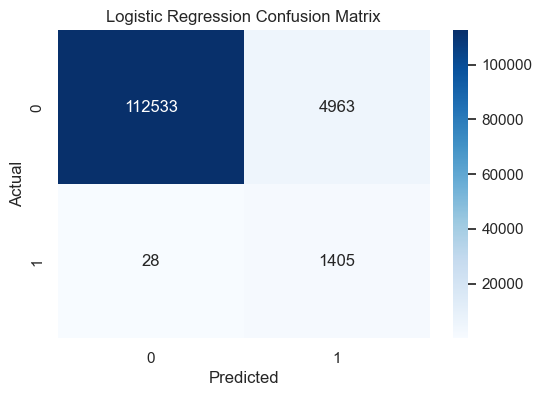

In [76]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred_log)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.title("Logistic Regression Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [77]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred_log)
print("Accuracy:", accuracy)

Accuracy: 0.9580337848632378


In [78]:
fraud_prob_log = log_model.predict_proba(X_test)[:,1]

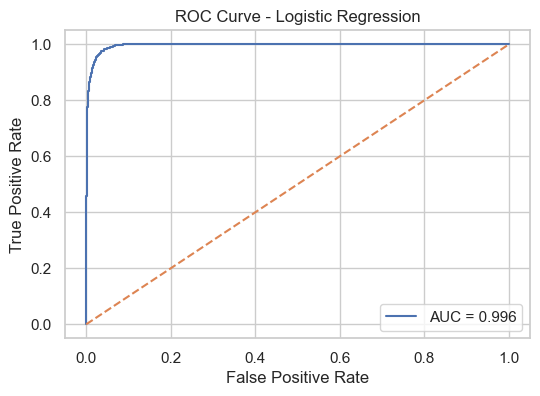

In [79]:
from sklearn.metrics import roc_curve, roc_auc_score

fpr, tpr, thresholds = roc_curve(y_test, fraud_prob_log)
auc_score = roc_auc_score(y_test, fraud_prob_log)

plt.figure(figsize=(6,4))
plt.plot(fpr, tpr, label=f"AUC = {auc_score:.3f}")
plt.plot([0,1],[0,1],'--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Logistic Regression")
plt.legend()

plt.show()

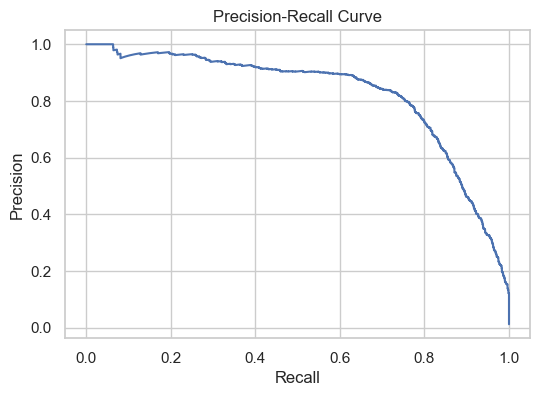

In [101]:
from sklearn.metrics import precision_recall_curve

precision, recall, _ = precision_recall_curve(y_test, fraud_prob_log)

plt.figure(figsize=(6,4))
plt.plot(recall, precision)

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")

plt.show()

In [107]:
import pandas as pd

feature_importance = pd.Series(
    log_model.coef_[0],
    index=X.columns
).sort_values(ascending=False)

print(feature_importance.head(30))

category_'es_leisure'              4.509077
category_'es_sportsandtoys'        2.741902
category_'es_travel'               2.173344
category_'es_hotelservices'        1.717434
category_'es_otherservices'        1.563211
category_'es_hyper'                0.645105
category_'es_home'                 0.573306
category_'es_health'               0.425254
category_'es_wellnessandbeauty'    0.385302
new_merchant                       0.152008
gender_'F'                         0.099604
merchant_freq                      0.022324
customer_avg_amount                0.016356
amount                             0.015456
step                               0.010811
age_1                              0.010537
rolling_std_5                      0.000854
gender_'U'                         0.000000
rolling_mean_5                    -0.000144
amount_deviation                  -0.000900
amount_zscore                     -0.001433
recent_txn_count                  -0.012443
transaction_count               

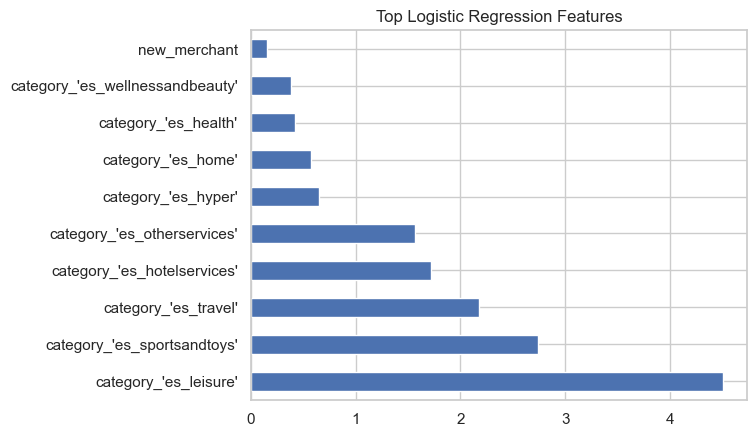

In [108]:
feature_importance.head(10).plot(kind='barh')
plt.title("Top Logistic Regression Features")
plt.show()

In [80]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=100,
    class_weight='balanced',
    random_state=42
)

rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

In [84]:
from sklearn.metrics import classification_report

print("Random Forest Evaluation:\n")
print(classification_report(y_test, y_pred_rf))

Random Forest Evaluation:

              precision    recall  f1-score   support

           0       1.00      1.00      1.00    117496
           1       0.91      0.70      0.80      1433

    accuracy                           1.00    118929
   macro avg       0.96      0.85      0.90    118929
weighted avg       1.00      1.00      1.00    118929



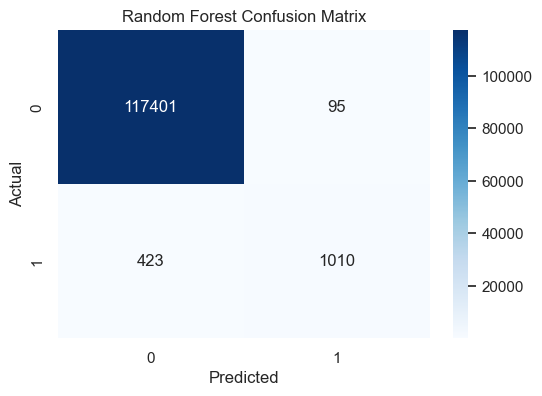

In [85]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.title("Random Forest Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [86]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred_rf)
print("Accuracy:", accuracy)

Accuracy: 0.9956444601400836


In [87]:
fraud_prob_rf = rf_model.predict_proba(X_test)[:,1]

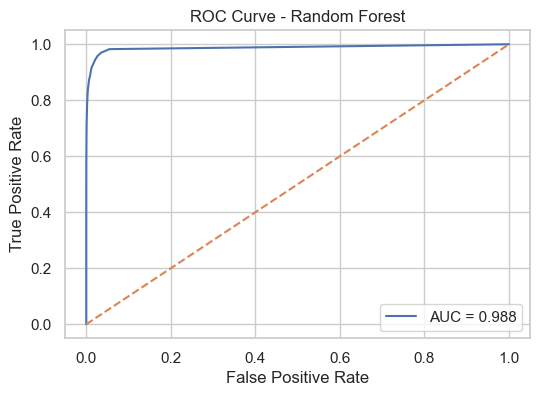

In [88]:
from sklearn.metrics import roc_curve, roc_auc_score

fpr, tpr, thresholds = roc_curve(y_test, fraud_prob_rf)
auc_score = roc_auc_score(y_test, fraud_prob_rf)

plt.figure(figsize=(6,4))
plt.plot(fpr, tpr, label=f"AUC = {auc_score:.3f}")
plt.plot([0,1],[0,1],'--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Random Forest")
plt.legend()

plt.show()

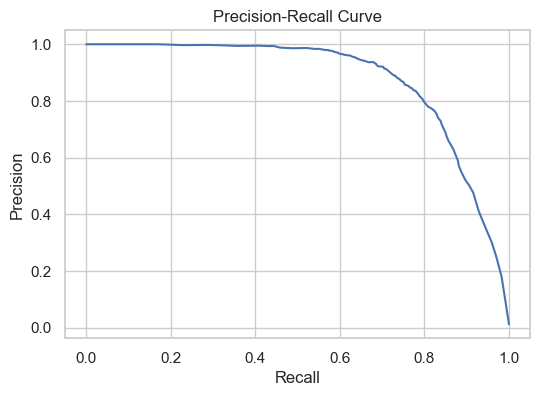

In [89]:
from sklearn.metrics import precision_recall_curve

precision, recall, _ = precision_recall_curve(y_test, fraud_prob_rf)

plt.figure(figsize=(6,4))
plt.plot(recall, precision)

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")

plt.show()

In [102]:
import pandas as pd

rf_feature_importance = pd.Series(
    rf_model.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

print(rf_feature_importance.head(10))

amount_log                      0.184531
amount                          0.173354
category_'es_transportation'    0.166992
customer_avg_amount             0.104791
merchant_freq                   0.077759
high_amount_flag                0.074120
amount_deviation                0.044786
rolling_mean_5                  0.029972
rolling_std_5                   0.029068
category_'es_sportsandtoys'     0.021809
dtype: float64


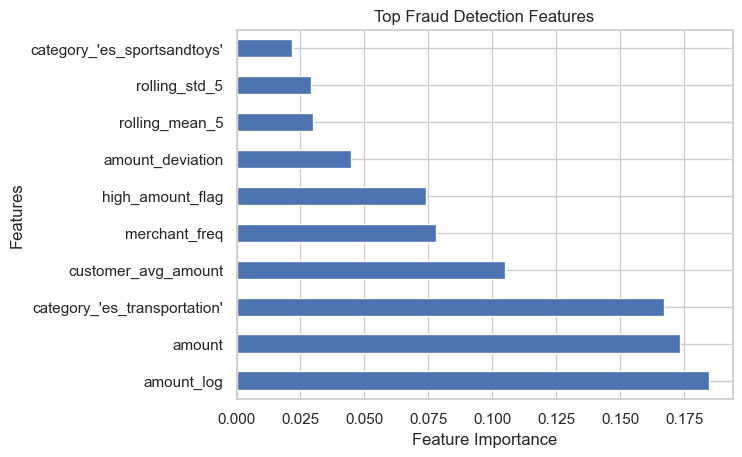

In [103]:
rf_feature_importance.head(10).plot(kind='barh')
plt.title("Top Fraud Detection Features")
plt.xlabel("Feature Importance")
plt.ylabel("Features")
plt.show()

In [90]:
from sklearn.ensemble import GradientBoostingClassifier

gb_model = GradientBoostingClassifier()

gb_model.fit(X_train, y_train)

y_pred_gb = gb_model.predict(X_test)

In [92]:
from sklearn.metrics import classification_report

print("Gradient Boosting Evaluation:\n")
print(classification_report(y_test, y_pred_gb))

Gradient Boosting Evaluation:

              precision    recall  f1-score   support

           0       1.00      1.00      1.00    117496
           1       0.85      0.74      0.79      1433

    accuracy                           1.00    118929
   macro avg       0.93      0.87      0.89    118929
weighted avg       1.00      1.00      1.00    118929



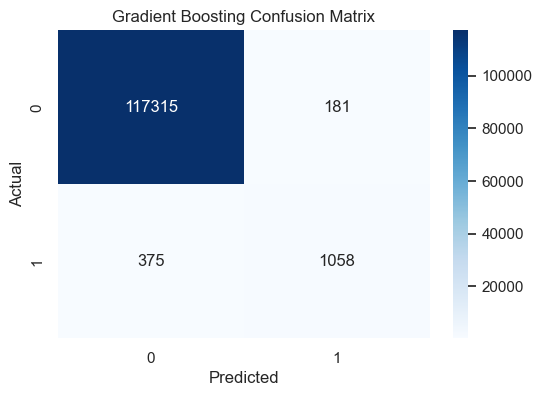

In [94]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred_gb)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.title("Gradient Boosting Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [95]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred_gb)
print("Accuracy:", accuracy)

Accuracy: 0.9953249417719816


In [96]:
fraud_prob_gb = gb_model.predict_proba(X_test)[:,1]

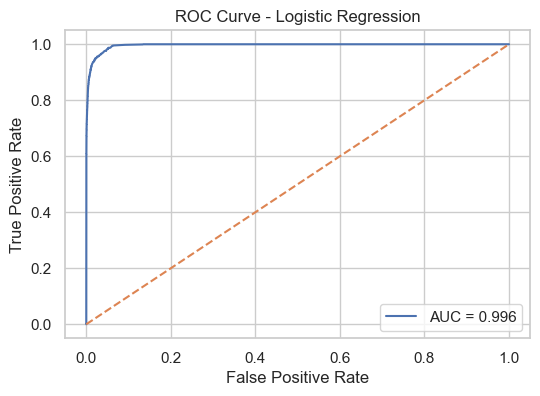

In [97]:
from sklearn.metrics import roc_curve, roc_auc_score

fpr, tpr, thresholds = roc_curve(y_test, fraud_prob_gb)
auc_score = roc_auc_score(y_test, fraud_prob_gb)

plt.figure(figsize=(6,4))
plt.plot(fpr, tpr, label=f"AUC = {auc_score:.3f}")
plt.plot([0,1],[0,1],'--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Logistic Regression")
plt.legend()

plt.show()

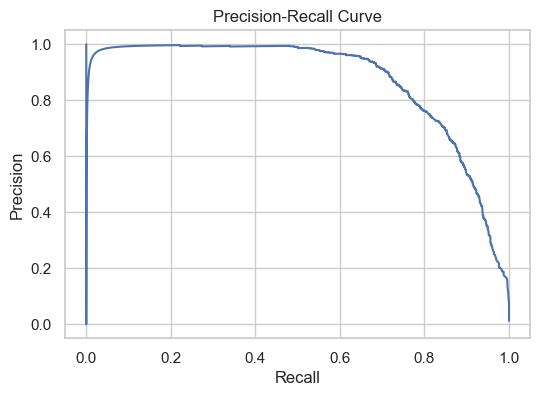

In [98]:
from sklearn.metrics import precision_recall_curve

precision, recall, _ = precision_recall_curve(y_test, fraud_prob_gb)

plt.figure(figsize=(6,4))
plt.plot(recall, precision)

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")

plt.show()

In [99]:
import pandas as pd

gb_feature_importance = pd.Series(
    gb_model.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

print(gb_feature_importance.head(10))

amount_log                      0.522931
customer_avg_amount             0.168008
amount                          0.071577
category_'es_sportsandtoys'     0.058465
category_'es_leisure'           0.030237
category_'es_transportation'    0.027337
amount_deviation                0.020479
category_'es_hyper'             0.019391
merchant_freq                   0.016938
category_'es_health'            0.013888
dtype: float64


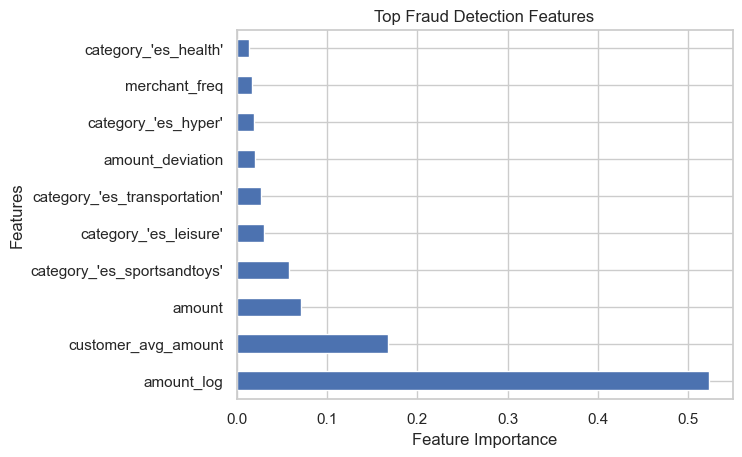

In [100]:
gb_feature_importance.head(10).plot(kind='barh')
plt.title("Top Fraud Detection Features")
plt.xlabel("Feature Importance")
plt.ylabel("Features")
plt.show()

# Confidence Score Calculation

In addition to predicting fraud likelihood, this project introduces a **confidence score** that measures how reliable the fraud prediction is.

The confidence score is derived from behavioral indicators such as:

- Number of anomaly signals triggered
- Repetition of anomalies over recent transactions
- Persistence of suspicious behavior

This allows the system to distinguish between:

- isolated anomalies
- consistent fraudulent patterns

The final system outputs two values:

Fraud Likelihood → how suspicious the transaction is  
Confidence Score → how reliable that suspicion is

In [1]:
#Fraud Probability using Logistic Regression
fraud_probability_log = log_model.predict_proba(X_test)[:,1]

NameError: name 'log_model' is not defined

In [ ]:
#Model certainty calculation
import numpy as np

model_certainty = np.abs(fraud_probability_log - 0.5) * 2

In [ ]:
#Anomaly score based on key features
anomaly_score = (
    X_test['high_amount_flag'] +
    X_test['new_merchant'] +
    (abs(X_test['amount_zscore']) > 2).astype(int)
)

In [ ]:
#Normalize anomaly score to 0-1 range
anomaly_score = anomaly_score / anomaly_score.max()

In [ ]:
#Confidence Score combining model certainty and anomaly score
confidence_score = (
    0.7 * model_certainty +
    0.3 * anomaly_score
)

# Conclusion

This project demonstrates how machine learning techniques can be applied to detect fraudulent banking transactions using behavioral analysis.

By combining anomaly detection with machine learning classification and confidence scoring, the system provides a more informative risk assessment framework.

Future improvements could include:

- Graph-based fraud detection
- Deep learning models
- Real-time fraud monitoring systems